# ☕ Coffee Shop Sales Analytics — PySpark End-to-End Project

**Dataset:** `Coffee_Shop_Dataset.csv` — ~149,000 transaction-level rows across 3 stores (New York City)
**Goal:** Build a production-style PySpark pipeline (Bronze → Silver → Gold / star schema) and answer
concrete business questions with window functions, broadcast joins, and aggregations.

This notebook is written as **interview-prep reading material** — every cell is commented to explain
not just *what* the code does but *why* it's written that way (schema design, join strategy, partitioning, etc.).

**Architecture:**

| Layer | Purpose |
|---|---|
| 🥉 Bronze | Raw ingestion, explicit schema, nothing dropped |
| 🥈 Silver | Cleaning, typing, de-dup, data-quality checks |
| 🥇 Gold | Star schema (`dim_date`, `dim_store`, `dim_product`, `fact_sales`) + analytics |


## 0. Imports & Setup

Standard PySpark + plotting imports. `matplotlib` uses the `Agg` backend so charts render inline without a display server.

In [1]:
%matplotlib inline
import os
import shutil

from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import (
    StructType, StructField, IntegerType, StringType, DoubleType, DateType
)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE_DIR      = os.path.abspath(".")
RAW_CSV_PATH  = os.path.join(BASE_DIR, "data", "coffee_shop.csv")
GOLD_DIR      = os.path.join(BASE_DIR, "outputs_nb", "gold")
CHARTS_DIR    = os.path.join(BASE_DIR, "outputs_nb", "charts")
SUMMARY_DIR   = os.path.join(BASE_DIR, "outputs_nb", "summaries")
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(SUMMARY_DIR, exist_ok=True)

COLORS = {
    "coffee_dark": "#4B2E2B", "coffee": "#6F4E37", "coffee_light": "#A9746E",
    "cream": "#E8DCCA", "gold": "#C89B3C", "green": "#5B8266", "red": "#B33A3A",
}
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": COLORS["coffee_dark"], "axes.labelcolor": COLORS["coffee_dark"],
    "xtick.color": COLORS["coffee_dark"], "ytick.color": COLORS["coffee_dark"],
    "text.color": COLORS["coffee_dark"], "font.size": 10,
})

## 1. Spark Session

`local[*]` runs Spark locally using all cores — fine for ~150K rows. On a real cluster this config would come from `spark-submit` instead.

In [2]:
spark = (
    SparkSession.builder
    .appName("CoffeeShopSalesAnalytics")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/06 21:50:23 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/08/06 21:50:23 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/usr/local/lib/python3.12/dist-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


26/08/06 21:50:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.2.0


## 2. 🥉 Bronze Layer — Raw Ingestion

We declare an **explicit schema** rather than `inferSchema=True`. Inference forces an extra pass over the
file and can guess types wrong; declaring the schema is faster and safer — standard practice for
production ingestion.

In [3]:
bronze_schema = StructType([
    StructField("transaction_id",   IntegerType(), True),
    StructField("transaction_date", StringType(),  True),
    StructField("transaction_time", StringType(),  True),
    StructField("store_id",         IntegerType(), True),
    StructField("store_location",   StringType(),  True),
    StructField("product_id",       IntegerType(), True),
    StructField("transaction_qty",  IntegerType(), True),
    StructField("unit_price",       DoubleType(),  True),
    StructField("product_category", StringType(),  True),
    StructField("product_type",     StringType(),  True),
    StructField("product_detail",   StringType(),  True),
    StructField("Size",             StringType(),  True),
    StructField("Total Bill",       DoubleType(),  True),
    StructField("Month Name",       StringType(),  True),
    StructField("Day Name",         StringType(),  True),
    StructField("Hour",             IntegerType(), True),
    StructField("Day of Week",      IntegerType(), True),
    StructField("Month",            IntegerType(), True),
])

bronze_df = (
    spark.read
    .option("header", True)
    .option("encoding", "UTF-8")
    .schema(bronze_schema)
    .csv(RAW_CSV_PATH)
)

bronze_count = bronze_df.count()
print(f"BRONZE: loaded {bronze_count:,} raw rows")
bronze_df.printSchema()

BRONZE: loaded 149,116 raw rows
root
 |-- transaction_id: integer (nullable = true)
 |-- transaction_date: string (nullable = true)
 |-- transaction_time: string (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- store_location: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- transaction_qty: integer (nullable = true)
 |-- unit_price: double (nullable = true)
 |-- product_category: string (nullable = true)
 |-- product_type: string (nullable = true)
 |-- product_detail: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Total Bill: double (nullable = true)
 |-- Month Name: string (nullable = true)
 |-- Day Name: string (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- Day of Week: integer (nullable = true)
 |-- Month: integer (nullable = true)



In [4]:
bronze_df.show(5)

+--------------+----------------+----------------+--------+--------------+----------+---------------+----------+----------------+-----------------+--------------+-----+----------+----------+--------+----+-----------+-----+
|transaction_id|transaction_date|transaction_time|store_id|store_location|product_id|transaction_qty|unit_price|product_category|     product_type|product_detail| Size|Total Bill|Month Name|Day Name|Hour|Day of Week|Month|
+--------------+----------------+----------------+--------+--------------+----------+---------------+----------+----------------+-----------------+--------------+-----+----------+----------+--------+----+-----------+-----+
|        114301|        6/1/2023|     11:33:29 AM|       3|       Astoria|        45|              1|       3.0|             Tea|Brewed herbal tea|    Peppermint|Large|       3.0|      June|Thursday|  11|          4|    6|
|        115405|        6/2/2023|     11:18:24 AM|       3|       Astoria|        45|              1|       

## 3. 🥈 Silver Layer — Cleaning & Business Rules

Steps: rename spaced columns to snake_case, parse date/time strings into real `timestamp`/`date` types,
trim strings, drop duplicates, filter structurally invalid rows, and **recompute revenue ourselves**
(`qty × unit_price`) to cross-check against the source `Total Bill` column — a classic silver-layer
data-quality gate.

In [5]:
silver_df = (
    bronze_df
    .withColumnRenamed("Total Bill", "total_bill_source")
    .withColumnRenamed("Size", "size")
    .withColumnRenamed("Month Name", "month_name")
    .withColumnRenamed("Day Name", "day_name")
    .withColumnRenamed("Hour", "hour_of_day")
    .withColumnRenamed("Day of Week", "day_of_week")
    .withColumnRenamed("Month", "month_num")
    .withColumn("store_location",   F.trim(F.col("store_location")))
    .withColumn("product_category", F.trim(F.col("product_category")))
    .withColumn("product_type",     F.trim(F.col("product_type")))
    .withColumn("product_detail",   F.trim(F.col("product_detail")))
    .withColumn("size",             F.trim(F.col("size")))
    .withColumn("transaction_date", F.to_date(F.col("transaction_date"), "M/d/yyyy"))
    .withColumn("transaction_ts",
                F.to_timestamp(
                    F.concat_ws(" ", F.col("transaction_date").cast("string"),
                                F.col("transaction_time")),
                    "yyyy-MM-dd h:mm:ss a"))
    .withColumn("total_amount",
                F.round(F.col("transaction_qty") * F.col("unit_price"), 2))
    .withColumn("revenue_mismatch_flag",
                F.abs(F.col("total_amount") - F.col("total_bill_source")) > 0.01)
    .drop("total_bill_source")
    .filter((F.col("transaction_qty") > 0) & (F.col("unit_price") > 0))
    .dropDuplicates(["transaction_id"])
)

silver_df.cache()
silver_count = silver_df.count()
mismatches = silver_df.filter(F.col("revenue_mismatch_flag")).count()

print(f"SILVER: {silver_count:,} clean rows ({bronze_count - silver_count:,} dropped)")
print(f"Revenue cross-check mismatches: {mismatches}")

SILVER: 149,116 clean rows (0 dropped)
Revenue cross-check mismatches: 0


In [6]:
silver_df.select('transaction_id','transaction_date','transaction_ts','total_amount','revenue_mismatch_flag').show(5)

+--------------+----------------+-------------------+------------+---------------------+
|transaction_id|transaction_date|     transaction_ts|total_amount|revenue_mismatch_flag|
+--------------+----------------+-------------------+------------+---------------------+
|            12|      2023-01-01|2023-01-01 07:44:35|         7.0|                false|
|            13|      2023-01-01|2023-01-01 07:45:51|         3.0|                false|
|            14|      2023-01-01|2023-01-01 07:48:19|         3.1|                false|
|            18|      2023-01-01|2023-01-01 08:00:18|         2.5|                false|
|            38|      2023-01-01|2023-01-01 09:00:24|         7.5|                false|
+--------------+----------------+-------------------+------------+---------------------+
only showing top 5 rows


## 4. 🥇 Gold Layer — Star Schema

Classic star schema: `fact_sales` (one row per transaction line, numeric measures + foreign keys) linked
to three dimension tables — `dim_date`, `dim_store`, `dim_product`. `date_id` is a `yyyyMMdd` integer
surrogate key, a common sort-friendly convention for date dimensions.

In [7]:
dim_date = (
    silver_df
    .select("transaction_date", "month_name", "day_name", "day_of_week", "month_num")
    .distinct()
    .withColumn("date_id", F.date_format("transaction_date", "yyyyMMdd").cast("int"))
    .withColumn("quarter", F.quarter("transaction_date"))
    .withColumn("is_weekend", F.col("day_name").isin("Saturday", "Sunday"))
    .select("date_id", F.col("transaction_date").alias("full_date"),
            "day_name", "day_of_week", "month_name", "month_num", "quarter", "is_weekend")
    .orderBy("date_id")
)

dim_store = silver_df.select("store_id", "store_location").distinct().orderBy("store_id")

dim_product = (
    silver_df
    .select("product_id", "product_category", "product_type", "product_detail", "size", "unit_price")
    .distinct()
    .orderBy("product_id")
)

fact_sales = (
    silver_df
    .withColumn("date_id", F.date_format("transaction_date", "yyyyMMdd").cast("int"))
    .select("transaction_id", "date_id", "store_id", "product_id",
            "hour_of_day", "transaction_qty", "unit_price", "total_amount")
)

print(f"dim_date    : {dim_date.count():,} rows")
print(f"dim_store   : {dim_store.count():,} rows")
print(f"dim_product : {dim_product.count():,} rows")
print(f"fact_sales  : {fact_sales.count():,} rows")

dim_date    : 181 rows


dim_store   : 3 rows


dim_product : 98 rows


fact_sales  : 149,116 rows


Persist the star schema as **partitioned Parquet** — columnar, compressed, and prunable on `month_num` for downstream BI/Spark jobs.

In [8]:
fact_with_month = (
    fact_sales.join(F.broadcast(dim_date.select("date_id", "month_num")), on="date_id", how="left")
)

for path in [os.path.join(GOLD_DIR, p) for p in ["dim_date", "dim_store", "dim_product", "fact_sales"]]:
    if os.path.exists(path):
        shutil.rmtree(path)

dim_date.write.mode("overwrite").parquet(os.path.join(GOLD_DIR, "dim_date"))
dim_store.write.mode("overwrite").parquet(os.path.join(GOLD_DIR, "dim_store"))
dim_product.write.mode("overwrite").parquet(os.path.join(GOLD_DIR, "dim_product"))
(fact_with_month.write.mode("overwrite").partitionBy("month_num")
 .parquet(os.path.join(GOLD_DIR, "fact_sales")))

print("Star schema written to outputs_nb/gold/ as Parquet.")

Star schema written to outputs_nb/gold/ as Parquet.


## 5. Analytics — Window Functions, Broadcast Joins & Aggregations

We join the fact table to all three dimensions using **`F.broadcast()`**. Since the dimension tables are
tiny (3 stores, 98 products, 181 dates) against a ~149K-row fact table, broadcasting ships a full copy of
each small table to every executor and avoids shuffling the large fact table across the network — the
standard "big fact, small dimension" join optimization.

In [9]:
sales = (
    fact_with_month
    .drop("month_num")
    .join(F.broadcast(dim_store),   on="store_id",   how="left")
    .join(F.broadcast(dim_product), on="product_id", how="left")
    .join(F.broadcast(dim_date),    on="date_id",     how="left")
)
sales.cache()
sales.count()

176011

In [10]:
def save_chart(fig, filename):
    fig.tight_layout()
    fig.savefig(os.path.join(CHARTS_DIR, filename), dpi=150, facecolor="white")
    plt.show()

def save_summary(pdf, filename):
    pdf.to_csv(os.path.join(SUMMARY_DIR, filename), index=False)

### 5a. Revenue by store & month + running cumulative total

A window function with `rowsBetween(unboundedPreceding, currentRow)` computes a running cumulative sum per store, ordered by month — the PySpark equivalent of a SQL `SUM(...) OVER (PARTITION BY ... ORDER BY ... ROWS UNBOUNDED PRECEDING)`.

In [11]:
store_month_revenue = (
    sales.groupBy("store_id", "store_location", "month_num", "month_name")
    .agg(F.round(F.sum("total_amount"), 2).alias("monthly_revenue"))
)

running_window = (
    Window.partitionBy("store_id").orderBy("month_num")
    .rowsBetween(Window.unboundedPreceding, Window.currentRow)
)
store_month_revenue = store_month_revenue.withColumn(
    "running_cumulative_revenue",
    F.round(F.sum("monthly_revenue").over(running_window), 2)
).orderBy("store_id", "month_num")

store_month_revenue.show(12, truncate=False)
save_summary(store_month_revenue.toPandas(), "store_month_revenue.csv")

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


+--------+---------------+---------+----------+---------------+--------------------------+
|store_id|store_location |month_num|month_name|monthly_revenue|running_cumulative_revenue|
+--------+---------------+---------+----------+---------------+--------------------------+
|3       |Astoria        |1        |January   |31645.66       |31645.66                  |
|3       |Astoria        |2        |February  |28614.84       |60260.5                   |
|3       |Astoria        |3        |March     |38018.68       |98279.18                  |
|3       |Astoria        |4        |April     |45403.61       |143682.79                 |
|3       |Astoria        |5        |May       |60216.76       |203899.55                 |
|3       |Astoria        |6        |June      |63518.11       |267417.66                 |
|5       |Lower Manhattan|1        |January   |32002.7        |32002.7                   |
|5       |Lower Manhattan|2        |February  |30098.9        |62101.6                   |

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


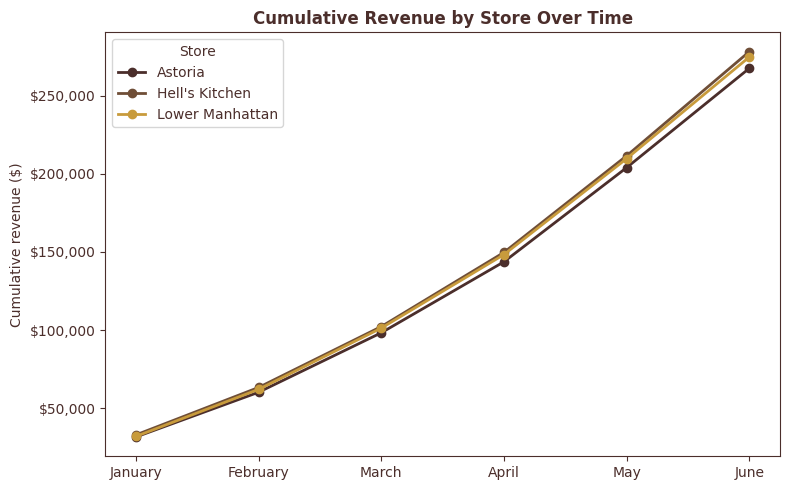

In [12]:
pdf_smr = store_month_revenue.toPandas().sort_values(["store_location", "month_num"])
fig, ax = plt.subplots(figsize=(8, 5))
palette = [COLORS["coffee_dark"], COLORS["coffee"], COLORS["gold"]]
for i, (loc, grp) in enumerate(pdf_smr.groupby("store_location")):
    ax.plot(grp["month_name"], grp["running_cumulative_revenue"], marker="o",
            label=loc, color=palette[i % len(palette)], linewidth=2)
ax.set_title("Cumulative Revenue by Store Over Time", fontweight="bold")
ax.set_ylabel("Cumulative revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(title="Store")
save_chart(fig, "01_cumulative_revenue_by_store.png")

### 5b. Month-over-month growth % using `LAG()`

`F.lag()` looks at the previous row within an ordered window — here, the previous month's revenue — to compute a percentage growth column, exactly like SQL `LAG(revenue) OVER (ORDER BY month)`.

In [13]:
total_by_month = (
    sales.groupBy("month_num", "month_name")
    .agg(F.round(F.sum("total_amount"), 2).alias("total_revenue"))
    .orderBy("month_num")
)
mom_window = Window.orderBy("month_num")
total_by_month = (
    total_by_month
    .withColumn("prev_month_revenue", F.lag("total_revenue").over(mom_window))
    .withColumn("mom_growth_pct",
                F.round((F.col("total_revenue") - F.col("prev_month_revenue"))
                        / F.col("prev_month_revenue") * 100, 2))
)
total_by_month.show(truncate=False)
save_summary(total_by_month.toPandas(), "month_over_month_growth.csv")

+---------+----------+-------------+------------------+--------------+
|month_num|month_name|total_revenue|prev_month_revenue|mom_growth_pct|
+---------+----------+-------------+------------------+--------------+
|1        |January   |96617.01     |NULL              |NULL          |
|2        |February  |89065.94     |96617.01          |-7.82         |
|3        |March     |116106.18    |89065.94          |30.36         |
|4        |April     |139850.83    |116106.18         |20.45         |
|5        |May       |183355.86    |139850.83         |31.11         |
|6        |June      |195165.46    |183355.86         |6.44          |
+---------+----------+-------------+------------------+--------------+



/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


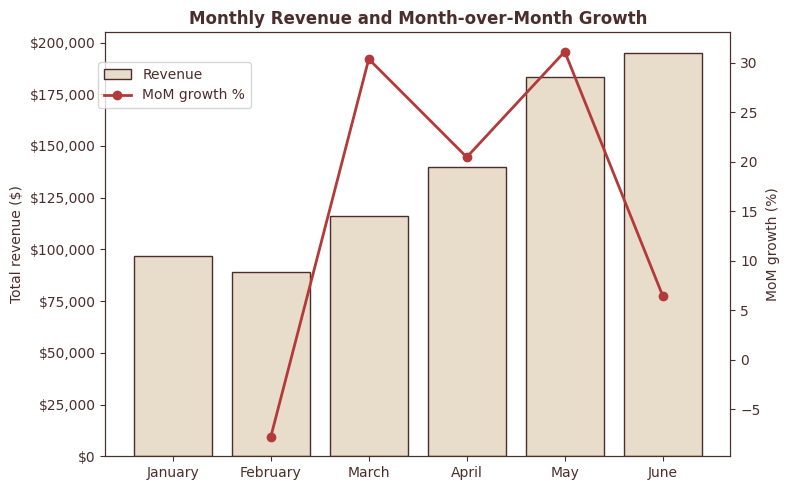

In [14]:
pdf_mom = total_by_month.toPandas()
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(pdf_mom["month_name"], pdf_mom["total_revenue"], color=COLORS["cream"],
        edgecolor=COLORS["coffee_dark"], label="Revenue")
ax1.set_ylabel("Total revenue ($)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2 = ax1.twinx()
ax2.plot(pdf_mom["month_name"], pdf_mom["mom_growth_pct"], color=COLORS["red"],
         marker="o", linewidth=2, label="MoM growth %")
ax2.set_ylabel("MoM growth (%)")
ax1.set_title("Monthly Revenue and Month-over-Month Growth", fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
save_chart(fig, "02_month_over_month_growth.png")

### 5c. Top-3 product types per category — `DENSE_RANK()`

`dense_rank()` over a window partitioned by category and ordered by revenue gives a per-group ranking without gaps, then we filter to rank ≤ 3 — the standard "top-N per group" pattern.

In [15]:
category_product_revenue = (
    sales.groupBy("product_category", "product_type")
    .agg(F.round(F.sum("total_amount"), 2).alias("revenue"),
         F.sum("transaction_qty").alias("units_sold"))
)
rank_window = Window.partitionBy("product_category").orderBy(F.desc("revenue"))
top_products_per_category = (
    category_product_revenue
    .withColumn("rank_in_category", F.dense_rank().over(rank_window))
    .filter(F.col("rank_in_category") <= 3)
    .orderBy("product_category", "rank_in_category")
)
top_products_per_category.show(30, truncate=False)
save_summary(top_products_per_category.toPandas(), "top_products_per_category.csv")

+------------------+---------------------+--------+----------+----------------+
|product_category  |product_type         |revenue |units_sold|rank_in_category|
+------------------+---------------------+--------+----------+----------------+
|Bakery            |Scone                |76283.85|21650     |1               |
|Bakery            |Pastry               |51311.98|13922     |2               |
|Bakery            |Biscotti             |39587.06|11576     |3               |
|Branded           |Housewares           |14888.0 |1110      |1               |
|Branded           |Clothing             |12326.0 |442       |2               |
|Coffee            |Barista Espresso     |100308.4|28205     |1               |
|Coffee            |Gourmet brewed coffee|70034.6 |25973     |2               |
|Coffee            |Premium brewed coffee|38781.15|12431     |3               |
|Coffee beans      |Organic Beans        |22482.0 |1038      |1               |
|Coffee beans      |Premium Beans       

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


### 5d. Store performance ranking — `RANK()`

In [16]:
store_performance = (
    sales.groupBy("store_id", "store_location")
    .agg(
        F.round(F.sum("total_amount"), 2).alias("total_revenue"),
        F.count("transaction_id").alias("total_transactions"),
        F.round(F.avg("total_amount"), 2).alias("avg_basket_value"),
    )
    .withColumn("revenue_rank", F.rank().over(Window.orderBy(F.desc("total_revenue"))))
    .orderBy("revenue_rank")
)
store_performance.show(truncate=False)
save_summary(store_performance.toPandas(), "store_performance.csv")

+--------+---------------+-------------+------------------+----------------+------------+
|store_id|store_location |total_revenue|total_transactions|avg_basket_value|revenue_rank|
+--------+---------------+-------------+------------------+----------------+------------+
|8       |Hell's Kitchen |278087.77    |60407             |4.6             |1           |
|5       |Lower Manhattan|274655.85    |57310             |4.79            |2           |
|3       |Astoria        |267417.66    |58294             |4.59            |3           |
+--------+---------------+-------------+------------------+----------------+------------+



/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


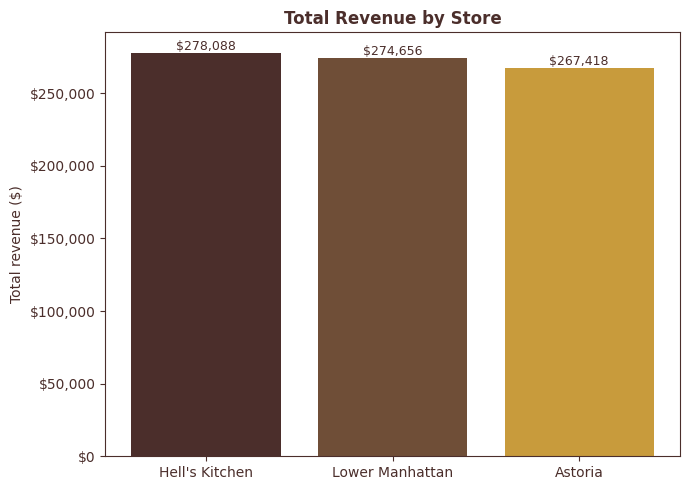

In [17]:
pdf_store = store_performance.toPandas()
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(pdf_store["store_location"], pdf_store["total_revenue"],
              color=[COLORS["coffee_dark"], COLORS["coffee"], COLORS["gold"]])
ax.set_title("Total Revenue by Store", fontweight="bold")
ax.set_ylabel("Total revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
for b in bars:
    ax.annotate(f"${b.get_height():,.0f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=9)
save_chart(fig, "03_revenue_by_store.png")

### 5e. Hour-of-day & day-of-week demand patterns

Simple `groupBy` aggregations reveal peak ordering hours and the busiest days — useful for staffing decisions.

In [18]:
hourly_pattern = (
    sales.groupBy("hour_of_day")
    .agg(F.count("transaction_id").alias("num_transactions"),
         F.round(F.sum("total_amount"), 2).alias("revenue"))
    .orderBy("hour_of_day")
)
hourly_pattern.show(24, truncate=False)
save_summary(hourly_pattern.toPandas(), "hourly_pattern.csv")

+-----------+----------------+---------+
|hour_of_day|num_transactions|revenue  |
+-----------+----------------+---------+
|6          |5457            |25937.47 |
|7          |16108           |75971.86 |
|8          |21071           |99430.78 |
|9          |21298           |101397.21|
|10         |22109           |104196.31|
|11         |11600           |53734.91 |
|12         |10050           |46227.63 |
|13         |10195           |47620.38 |
|14         |10555           |48529.8  |
|15         |10501           |48371.66 |
|16         |10506           |46847.17 |
|17         |10137           |46285.22 |
|18         |8633            |39274.74 |
|19         |7075            |32599.23 |
|20         |716             |3736.91  |
+-----------+----------------+---------+



/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


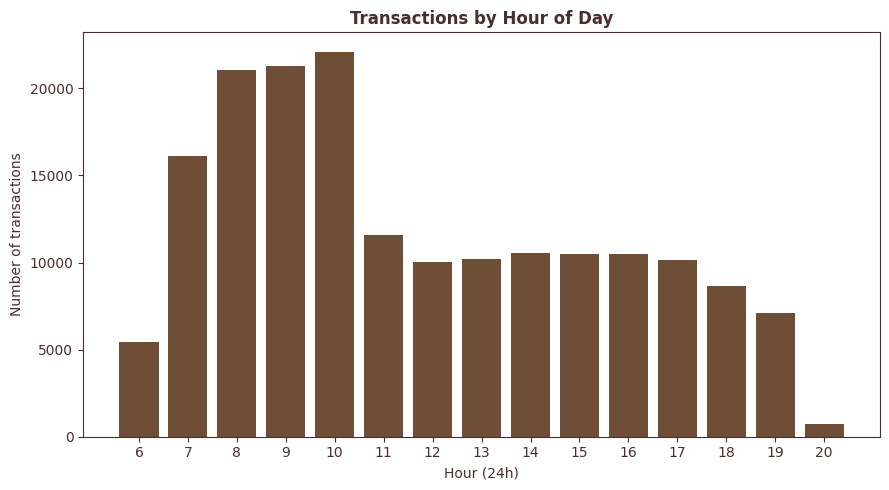

In [19]:
pdf_hour = hourly_pattern.toPandas()
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(pdf_hour["hour_of_day"], pdf_hour["num_transactions"], color=COLORS["coffee"])
ax.set_title("Transactions by Hour of Day", fontweight="bold")
ax.set_xlabel("Hour (24h)")
ax.set_ylabel("Number of transactions")
ax.set_xticks(pdf_hour["hour_of_day"])
save_chart(fig, "04_hourly_transaction_pattern.png")

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


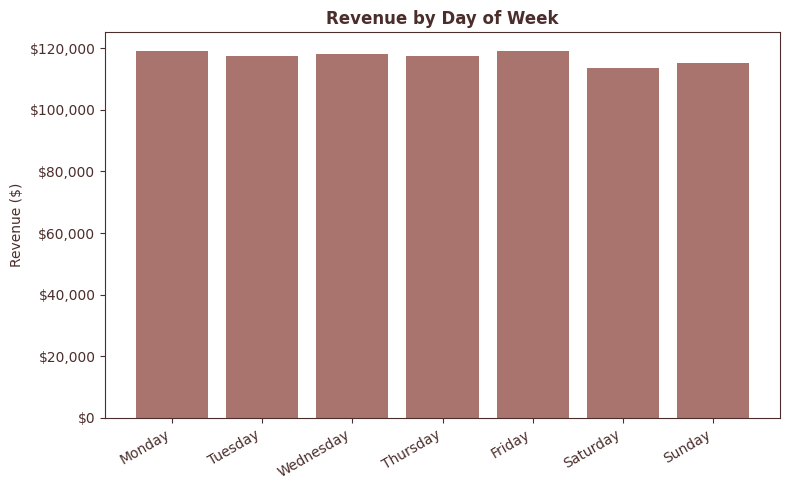

In [20]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_pattern = sales.groupBy("day_name").agg(F.round(F.sum("total_amount"), 2).alias("revenue"))
pdf_dow = dow_pattern.toPandas().set_index("day_name").reindex(day_order).reset_index()
save_summary(pdf_dow, "day_of_week_pattern.csv")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(pdf_dow["day_name"], pdf_dow["revenue"], color=COLORS["coffee_light"])
ax.set_title("Revenue by Day of Week", fontweight="bold")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
save_chart(fig, "05_revenue_by_day_of_week.png")

### 5f. Revenue share by product category

In [21]:
category_share = sales.groupBy("product_category").agg(F.round(F.sum("total_amount"), 2).alias("revenue"))
total_revenue_all = category_share.agg(F.sum("revenue")).collect()[0][0]
category_share = (
    category_share
    .withColumn("pct_of_total", F.round(F.col("revenue") / F.lit(total_revenue_all) * 100, 2))
    .orderBy(F.desc("revenue"))
)
category_share.show(truncate=False)
save_summary(category_share.toPandas(), "category_share.csv")

+------------------+---------+------------+
|product_category  |revenue  |pct_of_total|
+------------------+---------+------------+
|Coffee            |278854.65|34.0        |
|Tea               |196405.95|23.95       |
|Bakery            |167182.89|20.38       |
|Drinking Chocolate|72416.0  |8.83        |
|Coffee beans      |54057.75 |6.59        |
|Branded           |27214.0  |3.32        |
|Loose Tea         |11213.6  |1.37        |
|Flavours          |8408.8   |1.03        |
|Packaged Chocolate|4407.64  |0.54        |
+------------------+---------+------------+



/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


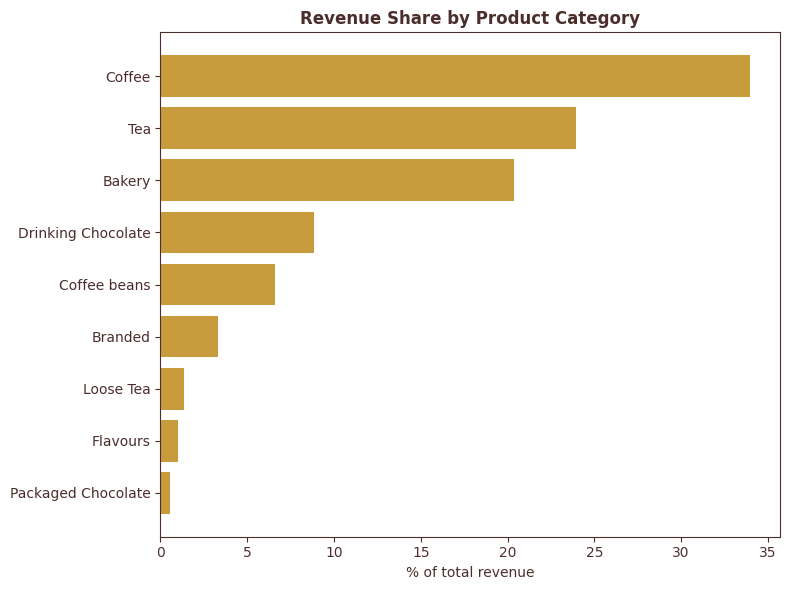

In [22]:
pdf_cat = category_share.toPandas().sort_values("revenue")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(pdf_cat["product_category"], pdf_cat["pct_of_total"], color=COLORS["gold"])
ax.set_title("Revenue Share by Product Category", fontweight="bold")
ax.set_xlabel("% of total revenue")
save_chart(fig, "06_category_revenue_share.png")

### 5g. Size mix (Small / Regular / Large) within each category

A self-join against per-category totals (also broadcast, since it's tiny) turns raw unit counts into within-category percentages.

In [23]:
size_mix = (
    sales.filter(F.col("size").isNotNull())
    .groupBy("product_category", "size")
    .agg(F.sum("transaction_qty").alias("units_sold"))
)
cat_totals = size_mix.groupBy("product_category").agg(F.sum("units_sold").alias("cat_total"))
size_mix = (
    size_mix.join(F.broadcast(cat_totals), on="product_category")
    .withColumn("pct_within_category", F.round(F.col("units_sold") / F.col("cat_total") * 100, 1))
    .orderBy("product_category", F.desc("units_sold"))
)
size_mix.show(30, truncate=False)
save_summary(size_mix.toPandas(), "size_mix.csv")

+------------------+-----------+----------+---------+-------------------+
|product_category  |size       |units_sold|cat_total|pct_within_category|
+------------------+-----------+----------+---------+-------------------+
|Bakery            |Not Defined|47148     |47148    |100.0              |
|Branded           |Not Defined|1552      |1552     |100.0              |
|Coffee            |Regular    |26250     |92512    |28.4               |
|Coffee            |Large      |25282     |92512    |27.3               |
|Coffee            |Small      |21423     |92512    |23.2               |
|Coffee            |Not Defined|19557     |92512    |21.1               |
|Coffee beans      |Not Defined|2446      |2446     |100.0              |
|Drinking Chocolate|Large      |9121      |17457    |52.2               |
|Drinking Chocolate|Regular    |8336      |17457    |47.8               |
|Flavours          |Not Defined|10511     |10511    |100.0              |
|Loose Tea         |Not Defined|1210  

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## 6. Wrap-Up

**Key takeaways from this run:**
- All three stores show steady month-over-month growth from January through June, with March and May
  the strongest growth months.
- Coffee, Tea and Bakery dominate revenue; a handful of product types make up most of category revenue
  (see the Top-3-per-category table).
- Demand peaks in the mid-morning hours, consistent with a commuter coffee-shop customer base.
- Regular/Large sizes dominate Coffee and Tea; Bakery and Branded items have no size dimension.

This notebook wrote the star schema to `outputs_nb/gold/` as partitioned Parquet and every chart/summary
table to `outputs_nb/charts/` and `outputs_nb/summaries/` — ready to plug into a BI tool or the next
stage of a pipeline (e.g. Hive external tables, Airflow-orchestrated refresh).

In [24]:
silver_df.unpersist()
sales.unpersist()
spark.stop()
print("Spark session stopped.")

Spark session stopped.
